# Proyecto Python y Power BI: Encuesta Satisfacción Clientes

Autor del Proyecto:

* Github_Autor: [OscarOspinaB](https://github.com/OscarOspinaB)

* Linkedin : [Perfil Linkedin](https://www.linkedin.com/in/oscar-ospina-bedoya/)

---

**Mínimo Producto Viable**

El objetivo de que los datos hayan sido limpiados para poder crear un Dashboard en Power BI ha sido cumplido. No obstante, el ejercicio está sujeto a mejora continua para obtener información de valor.

## 📊 Fuente de los datos
---

Los datos provienen de Kaggle, de la usuaria: `Data Regina`, pueden acceder al dataset desde el siguiente link:

[Datasets para Proyecto BI - Satisfacción Clientes](https://www.kaggle.com/datasets/dataregina/datasets-para-proyecto-bi-satisfaccin-clientes)



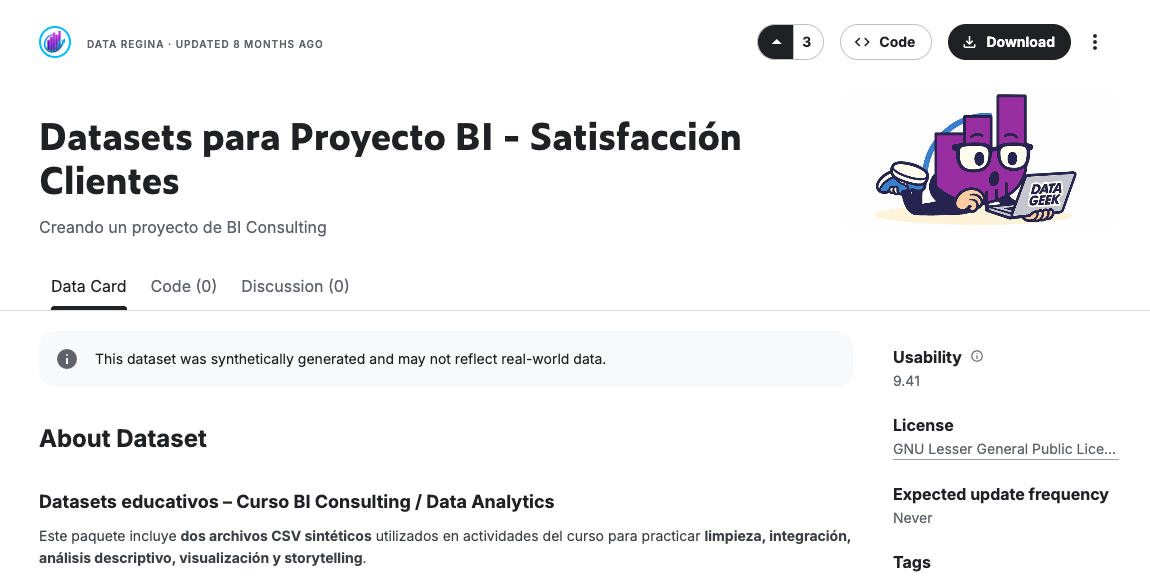

# 01 Importar Librerias o Modulos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.impute import SimpleImputer

#exportar desde Kaggle
import kagglehub
import os

# 02 Cargar Datos

## Exportar desde Kaggle

In [ ]:
#import kagglehub

# Download latest version
path = kagglehub.dataset_download("dataregina/datasets-para-proyecto-bi-satisfaccin-clientes")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'datasets-para-proyecto-bi-satisfaccin-clientes' dataset.
Path to dataset files: /kaggle/input/datasets-para-proyecto-bi-satisfaccin-clientes


In [ ]:
#import os

# Listar y ordenar alfabéticamente
archivos = sorted(os.listdir(path))

print("Archivos disponibles (ordenados):", archivos)


Archivos disponibles (ordenados): ['BI_Datos_Demograficos_Clientes.csv', 'BI_Satisfaccion_clientes.csv']


### Datos Encuesta Satisfaccion Clientes

In [ ]:
# Creamos la ruta completa al archivo (unimos la carpeta con el nombre del archivo)
# Si hay varios archivos, elige el nombre del que quieras abrir
nombre_archivo = archivos[1] # Esto toma el segundo archivo de la lista, que es 'BI_Satisfaccion_clientes.csv'
full_path = os.path.join(path, nombre_archivo)

# Leer los datos
encuesta = pd.read_csv(full_path, parse_dates=['Fecha de Encuesta'])

# Ver las primeras filas
encuesta.head()

,ID Cliente,Región,Servicio,Puntuación (1-10),Comentarios,Fecha de Encuesta
0,38,Norte,Atención al Cliente,10.0,Muy satisfecho con el servicio.,2024-01-05
1,38,Norte,Consultoría Legal,4.0,Resolución tardía del problema.,2024-01-17
2,10,Este,consultoria financiera,9.0,Recomendaría este servicio a otros.,2024-02-09
3,14,Norte,Consultoría Legal,9.0,Recomendaría este servicio a otros.,2024-03-24
4,34,Oeste,Consultoría Financiera,4.0,No resolvieron mi problema a tiempo.,2024-02-25


### Datos Demograficos Clientes

In [ ]:
# Creamos la ruta completa al archivo (unimos la carpeta con el nombre del archivo)
# Si hay varios archivos, elige el nombre del que quieras abrir
nombre_archivo = archivos[0] # Esto toma el primer archivo de la lista
full_path = os.path.join(path, nombre_archivo)

# Leer los datos
clientes= pd.read_csv(full_path)

# Ver las primeras filas
clientes.head()

,ID Cliente,Nombre,Apellido,Edad,Género,Ingresos Anuales,Nivel de Educación
0,1,Sarita,Pereira,40,Femenino,60000,Postgrado
1,2,Hortensia,Carreño,55,Femenino,30000,Postgrado
2,3,Benita,Moll,48,Femenino,30000,Universitario
3,4,Octavia,Pla,53,Femenino,75000,Terciario
4,5,Ángeles,Elorza,37,Femenino,25000,Universitario


# 03 Analisis Exploratorio y Limpieza

## 3.1 Dimensiones Datasets

In [ ]:
print(f'Clientes tiene {clientes.shape[0]} filas y {clientes.shape[1]} columnas')
print(f'Encuesta tiene {encuesta.shape[0]} filas y {encuesta.shape[1]} columnas')

Clientes tiene 40 filas y 7 columnas
Encuesta tiene 69 filas y 6 columnas


## 3.2 Campos Datasets

In [ ]:
#Columnas clientes
clientes.columns.sort_values()

Index(['Apellido', 'Edad', 'Género', 'ID Cliente', 'Ingresos Anuales',
       'Nivel de Educación', 'Nombre'],
      dtype='object')

In [ ]:
#Columnas encuesta
encuesta.columns.sort_values()

Index(['Comentarios', 'Fecha de Encuesta', 'ID Cliente', 'Puntuación (1-10)',
       'Región', 'Servicio'],
      dtype='object')

## 3.3 Información Datasets

In [ ]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID Cliente          40 non-null     int64 
 1   Nombre              40 non-null     object
 2   Apellido            40 non-null     object
 3   Edad                40 non-null     int64 
 4   Género              40 non-null     object
 5   Ingresos Anuales    40 non-null     int64 
 6   Nivel de Educación  40 non-null     object
dtypes: int64(3), object(4)
memory usage: 2.3+ KB


In [ ]:
encuesta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ID Cliente         69 non-null     int64         
 1   Región             69 non-null     object        
 2   Servicio           64 non-null     object        
 3   Puntuación (1-10)  68 non-null     float64       
 4   Comentarios        56 non-null     object        
 5   Fecha de Encuesta  69 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 3.4+ KB


## 3.4 Inspección Nulos

### Clientes

Conclusión:
No hay datos missing, por lo que se puede utilizar

In [ ]:
#cantidad total datos missing
clientes.isna().sum()

,0
ID Cliente,0
Nombre,0
Apellido,0
Edad,0
Género,0
Ingresos Anuales,0
Nivel de Educación,0


In [ ]:
# Porcentaje datos missing
clientes.isna().mean()*100

,0
ID Cliente,0.0
Nombre,0.0
Apellido,0.0
Edad,0.0
Género,0.0
Ingresos Anuales,0.0
Nivel de Educación,0.0


### Encuesta

Hay datos missing, por lo que se debe tratar

In [ ]:
#cantidad total datos missing
encuesta.isna().sum().sort_values(ascending = False)

,0
Comentarios,13
Servicio,5
Puntuación (1-10),1
ID Cliente,0
Región,0
Fecha de Encuesta,0


In [ ]:
# Porcentaje datos missing
np.round((encuesta.isna().mean()*100).sort_values(ascending=False), decimals=2)

,0
Comentarios,18.84
Servicio,7.25
Puntuación (1-10),1.45
ID Cliente,0.00
Región,0.00
Fecha de Encuesta,0.00


In [ ]:
# Presentar en una tabla tanto la cantidad como el % de vacios
is_na = encuesta.isna()

pd.DataFrame(data = {'total datos missing':is_na.sum(),
                     '% datos missing': np.round(is_na.mean() * 100, decimals = 2)}).sort_values(by = 'total datos missing', ascending = False)

,total datos missing,% datos missing
Comentarios,13,18.84
Servicio,5,7.25
Puntuación (1-10),1,1.45
ID Cliente,0,0.00
Región,0,0.00
Fecha de Encuesta,0,0.00


## 3.5 Tipo de datos

In [ ]:
clientes.dtypes

,0
ID Cliente,int64
Nombre,object
Apellido,object
Edad,int64
Género,object
Ingresos Anuales,int64
Nivel de Educación,object


In [ ]:
encuesta.dtypes

,0
ID Cliente,int64
Región,object
Servicio,object
Puntuación (1-10),float64
Comentarios,object
Fecha de Encuesta,datetime64[ns]


# 04 Limpieza datos

## 4.1 Limpieza datos tipograficos

### Fecha de Encuesta

Opté por corregir la fecha desde la carga de datos con:

```Python
parse_dates = ['Fecha de Encuesta']

In [ ]:
#encuesta['Fecha de Encuesta'] = pd.to_datetime(encuesta['Fecha de Encuesta'])

### Encuesta: Region

In [ ]:
encuesta['Región'].unique()

array(['Norte', 'Este', '   Norte', 'Oeste', 'Sur', 'norte',
       '         norte', '      Este'], dtype=object)

In [ ]:
# Eliminar espacios en blanco al inicio y al final y capitalizr
encuesta['Región'] = encuesta['Región'].str.strip().str.capitalize()

In [ ]:
# Validar que este limpio
encuesta['Región'].unique()

array(['Norte', 'Este', 'Oeste', 'Sur'], dtype=object)

### Encuesta: Servicio limpieza

In [ ]:
# Revisar el tipo de datos unicos que tiene Servicio
encuesta['Servicio'].unique()

array(['Atención al Cliente', 'Consultoría Legal',
       'consultoria financiera', 'Consultoría Financiera',
       'Atención Técnica', '       Atención al Cliente',
       'consultoria              financiera',
       'Atención           Técnica', nan, '        Consultoría Legal'],
      dtype=object)

In [ ]:
# Eliminar espacios en blanco al inicia y al final y capitalizar
encuesta['Servicio'] = encuesta['Servicio'].str.strip().str.capitalize()

In [ ]:
# Dejar un solo espacio en blanco entre palabras
encuesta['Servicio'] = encuesta['Servicio'].str.replace(r'\s+', ' ', regex=True)

In [ ]:
# Corregir Consultoría financiera
encuesta['Servicio'] = encuesta['Servicio'].str.replace('Consultoria financiera', 'Consultoría financiera')

In [ ]:
# Validar
encuesta['Servicio'].unique()

array(['Atención al cliente', 'Consultoría legal',
       'Consultoría financiera', 'Atención técnica', nan], dtype=object)

## 4.2 Duplicados

### Clientes: Duplicados

No hay duplicados en ID Cliente, por lo que no se aplica ningún tratamiento, en cuanto a la tabla de Encuesta, un cliente puede participar varias veces

In [ ]:
clientes.columns

Index(['ID Cliente', 'Nombre', 'Apellido', 'Edad', 'Género',
       'Ingresos Anuales', 'Nivel de Educación'],
      dtype='object')

In [ ]:
clientes.duplicated(subset = 'ID Cliente').sum()

np.int64(0)

In [ ]:
encuesta.columns

Index(['ID Cliente', 'Región', 'Servicio', 'Puntuación (1-10)', 'Comentarios',
       'Fecha de Encuesta'],
      dtype='object')

## 4.3 Fechas en el informe


In [ ]:
print(f'La fecha mínima de encuesta es :{encuesta['Fecha de Encuesta'].min()}')
print(f'La fecha máxima de encuesta es :{encuesta['Fecha de Encuesta'].max()}')

La fecha mínima de encuesta es :2024-01-03 00:00:00
La fecha máxima de encuesta es :2024-03-30 00:00:00


In [ ]:
encuesta.sort_values(by=['Fecha de Encuesta'], ascending = True).head()

,ID Cliente,Región,Servicio,Puntuación (1-10),Comentarios,Fecha de Encuesta
51,24,Sur,Atención técnica,2.0,Resolución tardía del problema.,2024-01-03
8,27,Norte,Atención al cliente,4.0,Necesita mejorar la comunicación.,2024-01-04
11,6,Norte,Consultoría financiera,2.0,Resolución tardía del problema.,2024-01-04
0,38,Norte,Atención al cliente,10.0,Muy satisfecho con el servicio.,2024-01-05
33,22,Norte,Consultoría legal,10.0,Excelente atención y seguimiento.,2024-01-07


In [ ]:
encuesta.sort_values(by=['Fecha de Encuesta'], ascending = True).tail()

,ID Cliente,Región,Servicio,Puntuación (1-10),Comentarios,Fecha de Encuesta
25,26,Oeste,Atención al cliente,10.0,NaN,2024-03-25
45,28,Este,Consultoría legal,8.0,Recomendaría este servicio a otros.,2024-03-26
59,11,Norte,Consultoría legal,4.0,"Buen servicio, pero lento.",2024-03-29
28,37,Norte,Atención técnica,4.0,Resolución tardía del problema.,2024-03-29
42,22,Norte,Consultoría financiera,7.0,Recomendaría este servicio a otros.,2024-03-30


## 4.4 Clientes: Añadir Columna

Dado que tengo las columnas Nombre y Apellido en la tabla **clientes**, quiero crear una de nombre completo

In [ ]:
clientes.columns

Index(['ID Cliente', 'Nombre', 'Apellido', 'Edad', 'Género',
       'Ingresos Anuales', 'Nivel de Educación'],
      dtype='object')

In [ ]:
clientes['Nombre Completo'] = clientes['Nombre']+' '+clientes['Apellido']

In [ ]:
#Validar que haya funcionado
clientes.head()

,ID Cliente,Nombre,Apellido,Edad,Género,Ingresos Anuales,Nivel de Educación,Nombre Completo
0,1,Sarita,Pereira,40,Femenino,60000,Postgrado,Sarita Pereira
1,2,Hortensia,Carreño,55,Femenino,30000,Postgrado,Hortensia Carreño
2,3,Benita,Moll,48,Femenino,30000,Universitario,Benita Moll
3,4,Octavia,Pla,53,Femenino,75000,Terciario,Octavia Pla
4,5,Ángeles,Elorza,37,Femenino,25000,Universitario,Ángeles Elorza


In [ ]:
# Eliminar las columnas Nombre y Apellido
cols_to_drop = ['Nombre','Apellido']
clientes = clientes.drop(columns = cols_to_drop)

In [ ]:
# Confirmar que ya está corregido
clientes.columns

Index(['ID Cliente', 'Edad', 'Género', 'Ingresos Anuales',
       'Nivel de Educación', 'Nombre Completo'],
      dtype='object')

In [ ]:
clientes.head()

,ID Cliente,Edad,Género,Ingresos Anuales,Nivel de Educación,Nombre Completo
0,1,40,Femenino,60000,Postgrado,Sarita Pereira
1,2,55,Femenino,30000,Postgrado,Hortensia Carreño
2,3,48,Femenino,30000,Universitario,Benita Moll
3,4,53,Femenino,75000,Terciario,Octavia Pla
4,5,37,Femenino,25000,Universitario,Ángeles Elorza


<Axes: ylabel='Puntuación (1-10)'>

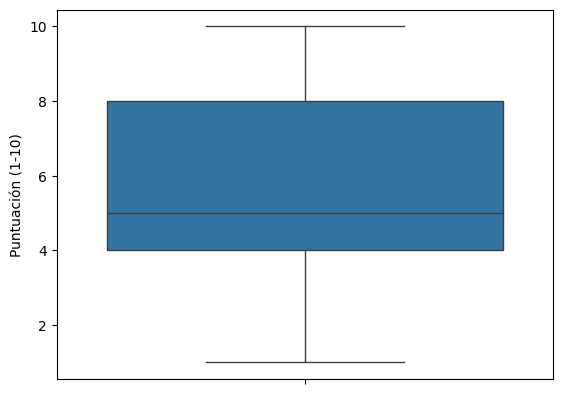

In [ ]:
sns.boxplot(data = encuesta, y = 'Puntuación (1-10)')

## 4.4 Encuesta: formato Puntuación
Dado que hay presencia de datos missing en esta columna, se requiere tratarlos antes de cambiar formato

In [ ]:
encuesta.columns

Index(['ID Cliente', 'Región', 'Servicio', 'Puntuación (1-10)', 'Comentarios',
       'Fecha de Encuesta'],
      dtype='object')

In [ ]:
# La serie es tipo float, pero debe ser tipo int
encuesta['Puntuación (1-10)'].dtypes

dtype('float64')

# 05 Tratamiento datos missing

## 5.1 Encuesta: Puntuación

In [ ]:
np.sort(encuesta['Puntuación (1-10)'].unique())

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., nan])

In [ ]:
encuesta['Puntuación (1-10)'].value_counts(dropna=False)

,count
Puntuación (1-10),
4.0,19
5.0,11
7.0,10
8.0,7
9.0,7
10.0,6
6.0,3
2.0,3
1.0,1


### Encuesta Promedio Imputar

In [ ]:
# Obtener la media de las variables numericas
encuesta.mean(numeric_only= True)

,0
ID Cliente,20.362319
Puntuación (1-10),6.000000


In [ ]:
# Obtener la media de las variables numericas
encuesta['Puntuación (1-10)'].mean(numeric_only= True)

np.float64(6.0)

In [ ]:
#utilizar SimpleImputer como estimador
imputer = SimpleImputer(strategy='mean')

# Aplicar el imputer solo a la columna 'Puntuación (1-10)'
encuesta['Puntuación (1-10)'] = imputer.fit_transform(encuesta[['Puntuación (1-10)']])

In [ ]:
#validar la media para la columna de Puntuacion
imputer.statistics_

array([6.])

In [ ]:
print(f'Los datos missing en Puntuación (1-10) despues de ser imputados son {encuesta['Puntuación (1-10)'].isna().sum()}')

Los datos missing en Puntuación (1-10) despues de ser imputados son 0


In [ ]:
# Validar que ya no tenga datos missing en encuesta
encuesta.isna().sum().sort_values(ascending = False)

,0
Comentarios,13
Servicio,5
Región,0
ID Cliente,0
Puntuación (1-10),0
Fecha de Encuesta,0


### Formato float a int

In [ ]:
# Validar el formato de la columna
encuesta.dtypes

,0
ID Cliente,int64
Región,object
Servicio,object
Puntuación (1-10),float64
Comentarios,object
Fecha de Encuesta,datetime64[ns]


In [ ]:
# Cambiar el tipo de float a int
encuesta['Puntuación (1-10)'] = encuesta['Puntuación (1-10)'].astype(int)

In [ ]:
#confirmar
encuesta.head(3)

,ID Cliente,Región,Servicio,Puntuación (1-10),Comentarios,Fecha de Encuesta
0,38,Norte,Atención al cliente,10,Muy satisfecho con el servicio.,2024-01-05
1,38,Norte,Consultoría legal,4,Resolución tardía del problema.,2024-01-17
2,10,Este,Consultoría financiera,9,Recomendaría este servicio a otros.,2024-02-09


## 5.2 Encuesta:Servicio

In [ ]:
# Revisar la cantidad de datos missing
encuesta.isna().sum().sort_values(ascending = False)

,0
Comentarios,13
Servicio,5
Región,0
ID Cliente,0
Puntuación (1-10),0
Fecha de Encuesta,0


In [ ]:
# Filtrar encuesta para mostrar filas donde 'Servicio' es NaN
encuesta.query(expr = 'Servicio.isna()')

,ID Cliente,Región,Servicio,Puntuación (1-10),Comentarios,Fecha de Encuesta
27,11,Norte,NaN,5,NaN,2024-03-21
39,11,Norte,NaN,5,NaN,2024-03-21
49,14,Norte,NaN,7,El tiempo de respuesta fue muy rápido.,2024-03-23
62,1,Sur,NaN,10,Excelente atención y seguimiento.,2024-02-13
67,14,Norte,NaN,7,El tiempo de respuesta fue muy rápido.,2024-03-23


###  Moda Imputar

In [ ]:
# Se observa que para Servicio la moda es Consultoria financiera
encuesta.describe(include = 'object')

,Región,Servicio,Comentarios
count,69,64,56
unique,4,4,8
top,Norte,Consultoría financiera,"Buen servicio, pero lento."
freq,36,29,13


In [ ]:
# forma mas precisa de ver la moda
encuesta['Servicio'].value_counts().index[0]

'Consultoría financiera'

In [ ]:
# El imputer unicamente a la columna Servicio
imputer_servicio = SimpleImputer(strategy='most_frequent').fit(X = encuesta[['Servicio']])
imputer_servicio.statistics_

array(['Consultoría financiera'], dtype=object)

In [ ]:
#Imputar
encuesta['Servicio'] = imputer_servicio.transform(X = encuesta[['Servicio']]).ravel()

In [ ]:
#Validar que no haya NaN en la columna
encuesta.isna().sum()

,0
ID Cliente,0
Región,0
Servicio,0
Puntuación (1-10),0
Comentarios,13
Fecha de Encuesta,0


## 5.3 Encuesta: Comentarios

In [ ]:
# Filtrar encuesta para mostrar filas donde 'Comentarios' es NaN
encuesta.query(expr = 'Comentarios.isna()')

,ID Cliente,Región,Servicio,Puntuación (1-10),Comentarios,Fecha de Encuesta
6,22,Oeste,Consultoría legal,8,NaN,2024-03-14
24,16,Norte,Atención técnica,6,NaN,2024-03-17
25,26,Oeste,Atención al cliente,10,NaN,2024-03-25
27,11,Norte,Consultoría financiera,5,NaN,2024-03-21
37,8,Oeste,Consultoría financiera,4,NaN,2024-02-16
39,11,Norte,Consultoría financiera,5,NaN,2024-03-21
40,9,Norte,Consultoría financiera,7,NaN,2024-02-24
41,30,Norte,Atención al cliente,9,NaN,2024-03-15
47,19,Sur,Atención técnica,7,NaN,2024-02-21
53,34,Norte,Consultoría financiera,3,NaN,2024-01-31


In [ ]:
# Al ser comentarios, se tomó la decisión de que solo se reemplazen los NaN con
# la expresión Sin comentarios
encuesta['Comentarios'] = encuesta['Comentarios'].fillna(value = 'Sin comentarios')

In [ ]:
#validar que no hayan nulos
encuesta.isna().sum()

,0
ID Cliente,0
Región,0
Servicio,0
Puntuación (1-10),0
Comentarios,0
Fecha de Encuesta,0


In [ ]:
encuesta.query(expr = 'Comentarios.isna()')

,ID Cliente,Región,Servicio,Puntuación (1-10),Comentarios,Fecha de Encuesta


# 06 Outliers

## Boxplot: Puntuación Encuesta

In [ ]:
fig = px.box(encuesta,
             y = 'Puntuación (1-10)',
             title = 'Distribución de Puntuaciones Encuesta',
             color_discrete_sequence = px.colors.qualitative.Prism)
fig.show()

## Boxplot: Puntuación Región

In [ ]:
fig_box_region = px.box(encuesta,
             x="Región",
             y="Puntuación (1-10)",
             color="Región",
             title="Puntuación por Región",
             color_discrete_sequence = px.colors.qualitative.Antique)
fig_box_region.show()

## Boxplot: Puntuación por Servicio

In [ ]:
fig_box_servicio = px.box(encuesta,
             x="Servicio",
             y="Puntuación (1-10)",
             color="Servicio",
             title="Puntuación por Servicio",
             color_discrete_sequence= px.colors.qualitative.Vivid)
#fig_box_servicio.update_xaxes(tickangle=-45)
fig_box_servicio.show()

# 📁 07 Convertir en CSV

Esto es con el objetivo de exportar los datos a Power BI y generar un dashboard con lo datos limpios

## csv clientes

In [ ]:
clientes.to_csv('clientes.csv', index = False)

## csv encuesta

In [ ]:
encuesta.to_csv('encuesta.csv',index = False)

# 08 Estadistica Descriptiva

In [ ]:
encuesta['Puntuación (1-10)'].describe().round(2)

,Puntuación (1-10)
count,69.00
mean,6.00
std,2.32
min,1.00
25%,4.00
50%,5.00
75%,8.00
max,10.00


In [ ]:
encuesta.describe(include = 'object')

,Región,Servicio,Comentarios
count,69,69,69
unique,4,4,9
top,Norte,Consultoría financiera,"Buen servicio, pero lento."
freq,36,34,13


In [ ]:
encuesta.describe(include = 'datetime')

,Fecha de Encuesta
count,69
mean,2024-02-18 05:33:54.782608640
min,2024-01-03 00:00:00
25%,2024-01-30 00:00:00
50%,2024-02-16 00:00:00
75%,2024-03-12 00:00:00
max,2024-03-30 00:00:00


In [ ]:
encuesta['Fecha de Encuesta'].min()

Timestamp('2024-01-03 00:00:00')

In [ ]:
encuesta['Fecha de Encuesta'].max()

Timestamp('2024-03-30 00:00:00')

# 09 Tablas Dinámicas

## Región Respuesta

In [ ]:
pd.DataFrame(encuesta.groupby(by = 'Región')['Puntuación (1-10)'].agg(['count','mean','median']).round(2))

,count,mean,median
Región,,,
Este,11,4.82,5.0
Norte,36,5.92,5.5
Oeste,8,6.50,6.0
Sur,14,6.86,7.5


In [ ]:
# Ver totales
pd.pivot_table(encuesta, index = ['Región'], values = 'Puntuación (1-10)', aggfunc = ['count', 'mean', 'median'], margins = True).round(2)

,count,mean,median
,Puntuación (1-10),Puntuación (1-10),Puntuación (1-10)
Región,,,
Este,11,4.82,5.0
Norte,36,5.92,5.5
Oeste,8,6.50,6.0
Sur,14,6.86,7.5
All,69,6.00,5.0


## Servicio Respuesta

In [ ]:
pd.DataFrame(encuesta.groupby(by = 'Servicio')['Puntuación (1-10)'].agg(['count','mean','median']).round(2))

,count,mean,median
Servicio,,,
Atención al cliente,9,6.78,6.0
Atención técnica,11,5.64,5.0
Consultoría financiera,34,5.85,5.5
Consultoría legal,15,6.13,5.0


In [ ]:
# Ver totales
pd.pivot_table(encuesta, index = ['Servicio'], values = 'Puntuación (1-10)', aggfunc = ['count', 'mean', 'median'], margins = True).round(2)

,count,mean,median
,Puntuación (1-10),Puntuación (1-10),Puntuación (1-10)
Servicio,,,
Atención al cliente,9,6.78,6.0
Atención técnica,11,5.64,5.0
Consultoría financiera,34,5.85,5.5
Consultoría legal,15,6.13,5.0
All,69,6.00,5.0


## Región y Servicio

In [ ]:
pd.DataFrame(encuesta.groupby(by = ['Región','Servicio'])['Puntuación (1-10)'].agg(['count','mean','median']).round(2))

count  mean  median
Región Servicio                                   
Este   Atención al cliente         1  4.00     4.0
       Atención técnica            1  6.00     6.0
       Consultoría financiera      7  4.71     5.0
       Consultoría legal           2  5.00     5.0
Norte  Atención al cliente         6  7.00     7.5
       Atención técnica            5  5.40     4.0
       Consultoría financiera     17  5.59     6.0
       Consultoría legal           8  6.12     5.0
Oeste  Atención al cliente         2  7.50     7.5
       Consultoría financiera      4  4.75     4.0
       Consultoría legal           2  9.00     9.0
Sur    Atención técnica            5  5.80     5.0
       Consultoría financiera      6  8.67     8.5
       Consultoría legal           3  5.00     4.0

In [ ]:
# Formato tabular
tabla_tabular = pd.DataFrame(encuesta.groupby(by = ['Región','Servicio'])['Puntuación (1-10)'].agg(['count','mean','median']).round(2)).unstack()
tabla_tabular

count                                          \
Servicio Atención al cliente Atención técnica Consultoría financiera   
Región                                                                 
Este                     1.0              1.0                    7.0   
Norte                    6.0              5.0                   17.0   
Oeste                    2.0              NaN                    4.0   
Sur                      NaN              5.0                    6.0   

                                          mean                   \
Servicio Consultoría legal Atención al cliente Atención técnica   
Región                                                            
Este                   2.0                 4.0              6.0   
Norte                  8.0                 7.0              5.4   
Oeste                  2.0                 7.5              NaN   
Sur                    3.0                 NaN              5.8   

                                                               median  \
Servicio Consultoría financiera Consultoría legal Atención al cliente   
Región                                                                  
Este                       4.71              5.00                 4.0   
Norte                      5.59              6.12                 7.5   
Oeste                      4.75              9.00                 7.5   
Sur                        8.67              5.00                 NaN   

                                                                    
Servicio Atención técnica Consultoría financiera Consultoría legal  
Región                                                              
Este                  6.0                    5.0               5.0  
Norte                 4.0                    6.0               5.0  
Oeste                 NaN                    4.0               9.0  
Sur                   5.0                    8.5               4.0

In [ ]:
# Poner color
# Los Nulos se pintan de blanco
tabla_tabular.style.background_gradient(cmap='YlOrRd').highlight_null(color='white').format("{:.2f}")


In [ ]:
# Ver totales
pd.pivot_table(encuesta, index=['Región', 'Servicio'], values='Puntuación (1-10)', aggfunc=['count', 'mean', 'median'], margins=True).round(2)

count              mean  \
                              Puntuación (1-10) Puntuación (1-10)   
Región Servicio                                                     
Este   Atención al cliente                    1              4.00   
       Atención técnica                       1              6.00   
       Consultoría financiera                 7              4.71   
       Consultoría legal                      2              5.00   
Norte  Atención al cliente                    6              7.00   
       Atención técnica                       5              5.40   
       Consultoría financiera                17              5.59   
       Consultoría legal                      8              6.12   
Oeste  Atención al cliente                    2              7.50   
       Consultoría financiera                 4              4.75   
       Consultoría legal                      2              9.00   
Sur    Atención técnica                       5              5.80   
       Consultoría financiera                 6              8.67   
       Consultoría legal                      3              5.00   
All                                          69              6.00   

                                         median  
                              Puntuación (1-10)  
Región Servicio                                  
Este   Atención al cliente                  4.0  
       Atención técnica                     6.0  
       Consultoría financiera               5.0  
       Consultoría legal                    5.0  
Norte  Atención al cliente                  7.5  
       Atención técnica                     4.0  
       Consultoría financiera               6.0  
       Consultoría legal                    5.0  
Oeste  Atención al cliente                  7.5  
       Consultoría financiera               4.0  
       Consultoría legal                    9.0  
Sur    Atención técnica                     5.0  
       Consultoría financiera               8.5  
       Consultoría legal                    4.0  
All                                         5.0

# 10 📶  Visualización:Encuesta

Si bien el propósito del proyecto es generar un Dashboard en Power BI tras haber limpiado e imputado los datos nulos, se plantean gráficos que resuman la información que complementen el análisis

In [ ]:
encuesta.columns

Index(['ID Cliente', 'Región', 'Servicio', 'Puntuación (1-10)', 'Comentarios',
       'Fecha de Encuesta'],
      dtype='object')

## Torta: Región Respuesta

In [ ]:
px.pie(encuesta,
       names = 'Región',
       title = 'Proporción por Región',
       color_discrete_sequence = px.colors.qualitative.Bold,
       hole = 0.5)

## Hist: Respuesta por Servicio y Región

In [ ]:
fig_puntuacion = px.histogram(encuesta,
             x = 'Servicio',
             title = 'Distribución por Puntuación (1-10) por Servicio',
             color = 'Región',
             barmode = 'group',
             color_discrete_sequence = px.colors.qualitative.Antique,
             nbins = 10,
             text_auto = True
             )

fig_puntuacion.show()

## Torta: Respuesta por Servicio

In [ ]:
px.pie(encuesta,
       names = 'Servicio',
       title = 'Proporción por Servicio',
       color_discrete_sequence = px.colors.qualitative.Prism,
       hole = 0.5)